In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import gamma


In [80]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel = model.merge_inference(node,grid_width= 15,sd=sigma)
        print(np.min(sel))
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

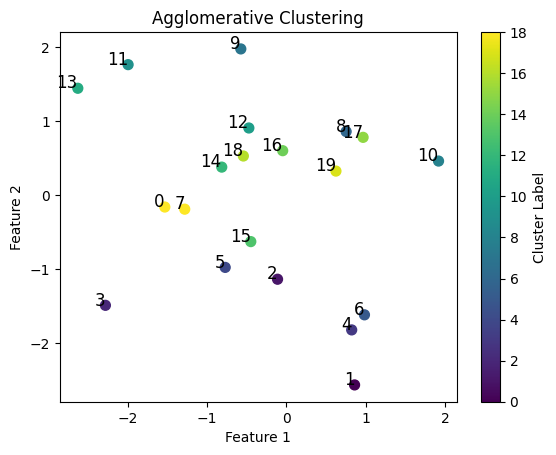

In [77]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=50, centers=3, cluster_std=1,random_state=42)
n=20
p=20
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=np.log(20), n_clusters=19,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [78]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob = model.merge_inference(node)

level:  1


In [79]:
sel_prob

array([ -7.0813649 ,  -7.09262409,  -7.10390751,  -7.11521515,
        -7.12654701,  -7.1379031 ,  -7.1492834 ,  -7.16068793,
        -7.17211668,  -7.18356966,  -7.19504685,  -7.20654827,
        -7.21807391,  -7.22962378,  -7.24119786,  -7.25279617,
        -7.2644187 ,  -7.27606545,  -7.28773643,  -7.29943162,
        -7.31115104,  -7.32289469,  -7.33466255,  -7.34645464,
        -7.35827094,  -7.37011148,  -7.38197623,  -7.3938652 ,
        -7.4057784 ,  -7.41771582,  -7.42967747,  -7.44166333,
        -7.45367342,  -7.46570773,  -7.47776626,  -7.48984901,
        -7.50195599,  -7.51408719,  -7.52624261,  -7.53842225,
        -7.55062612,  -7.56285421,  -7.57510652,  -7.58738305,
        -7.59968381,  -7.61200878,  -7.62435798,  -7.63673141,
        -7.64912905,  -7.66155092,  -7.67399701,  -7.68646732,
        -7.69896185,  -7.71148061,  -7.72402359,  -7.73659079,
        -7.74918221,  -7.76179785,  -7.77443772,  -7.78710181,
        -7.79979012,  -7.81250266,  -7.82523942,  -7.83

In [9]:
pvalue

np.float64(0.00030702601575409644)

In [10]:
X[[0,2],:].mean(axis=0)

array([0.61571044, 0.3746591 ])

In [11]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)**2) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=15
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

In [12]:
norm_nu = nu/np.linalg.norm(nu)
print(np.isclose(np.linalg.norm(X.T@norm_nu), np.linalg.norm(X.T@nu)/np.linalg.norm(nu)))

True


In [13]:
model._approx_log_reference(node, stat_grid, nuisance,dir, sd=1)

level:  1
[[0.00014142]]
[[0.89735113]]
[[2.33444797]]
[[0.83691378]]
[[0.87249814]]
[[2.09722278]]
[[0.83780856]]
[[2.68432252]]
[[2.76177505]]
[[0.57603764]]
[[0.53740202]]
[[1.32745783]]
[[0.88773372]]
[[0.76907506]]
[[0.40623265]]
[[1.339088]]
[[1.82882816]]
[[0.97294484]]
[[0.40637389]]
[[1.48736344]]
[[1.90162442]]
[[0.78058279]]
[[1.5969392]]
[[2.56973696]]
[[1.54858692]]
[[2.12920225]]
[[2.04874841]]
[[1.25846994]]
[[0.56265355]]
[[0.53540012]]
[[0.62630064]]
[[1.15180137]]
[[1.30347016]]
[[1.23748971]]
[[1.77684985]]
[[0.5619504]]
[[1.30361123]]
[[1.14559581]]
[[2.66773782]]
[[2.31536069]]
[[2.25428821]]
[[3.17157255]]
[[0.46939079]]
[[3.3676008]]
[[2.89780993]]
[[1.81969081]]
[[1.44347272]]
[[2.52687455]]
[[1.77224158]]
[[2.6012969]]
[[3.13781715]]
[[0.91984791]]
[[2.45978503]]
[[2.60139088]]
[[3.00304658]]
[[1.70907357]]
[[2.9142143]]
[[0.99588858]]
[[2.9096138]]
[[2.01087339]]
[[0.76362969]]
[[0.99179145]]
[[1.30707147]]
[[0.1913569]]
[[1.51146143]]
[[1.13429172]]
[[0.53680

array([ -38.7006036 ,  -39.66708383,  -40.65725626,  -41.67151819,
        -42.70813992,  -43.7622436 ,  -44.8409397 ,  -45.94453815,
        -47.07293879,  -48.22606395,  -49.40396073,  -50.60657085,
        -51.83256334,  -53.07822917,  -54.34657567,  -55.64075998,
        -56.96198042,  -58.31114625,  -59.6891645 ,  -61.09693234,
        -62.53528086,  -64.00494677,  -65.50657457,  -67.0407287 ,
        -68.60791182,  -70.20857846,  -71.84315083,  -73.51202752,
        -75.21559714,  -76.95423819,  -78.72832967,  -80.53824605,
        -82.38435964,  -84.26703159,  -86.18662004,  -88.14346639,
        -90.13789855,  -92.17022878,  -94.24075256,  -96.34974914,
        -98.49748136, -100.68419643, -102.91012679, -105.17549089,
       -107.48049412, -109.82532968, -112.2101795 , -114.63521496,
       -117.1005977 , -119.60648033, -122.15300711, -124.74031448,
       -127.36853169, -130.0377813 , -132.74817961, -135.49983714,
       -138.29285901, -141.12734531, -144.00339142, -146.92108

level:  1
-305.6907349372618
level:  1
-290.8563932431281
level:  1
-298.7674698900987
level:  1
-294.2795110614379
level:  1
-296.88650539111495
level:  1
-297.17263129150547
level:  1
-296.7814734791764
level:  1
-299.6103488158037
level:  1
-293.7577749746772
level:  1
-298.18195800102717
level:  1
-303.0316884758631
level:  1
-298.66855009268556
level:  1
-301.4667214283934
level:  1
-293.9643176520774
level:  1
-297.35301176352345
level:  1
-299.3767416085202
level:  1
-293.875734010893
level:  1
-302.0747776246451
level:  1
-294.3380126558957
level:  1
-294.30381928378574
level:  1
-295.15799437444934
level:  1
-303.77740084754873
level:  1
-299.38564518825706
level:  1
-296.5020370433349
level:  1
-299.51121208515406
level:  1
-293.69879346454104
level:  1
-303.3489686266771
level:  1
-300.32758551334814
level:  1
-293.8719891902583
level:  1
-295.2746281601783
level:  1
-296.75418080573763
level:  1
-292.3370761187896
level:  1
-300.5013857122244
level:  1
-301.8677391473525
le

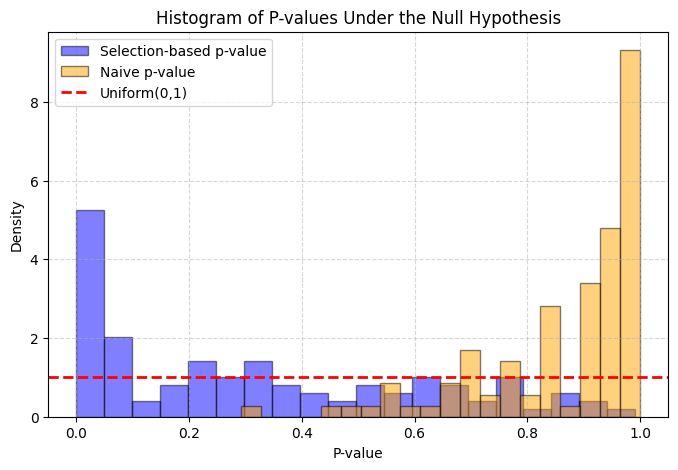

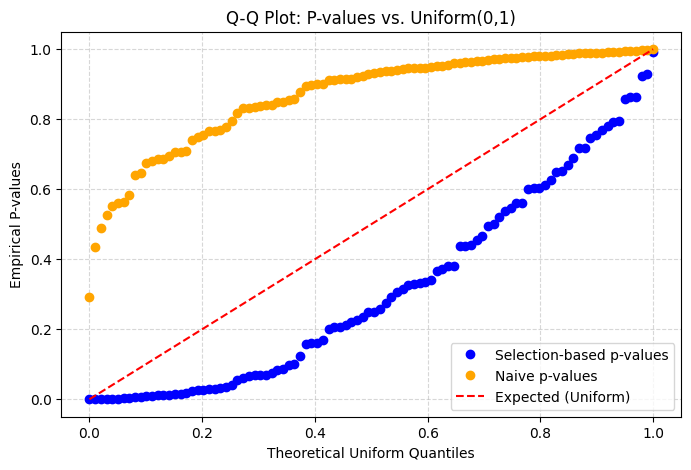

In [81]:
check_p_value_uniformity(20,2,1,19,1,-1,100)

level:  1
-43.34806357043588
level:  1
-43.37939136538469
level:  1
-43.676915235796386
level:  1
-43.98444289041281
level:  1
-44.00592209013416
level:  1
-43.770862828100604
level:  1
-44.69747885966822
level:  1
-44.44115158527153
level:  1
-44.44887077905274
level:  1
-44.62964387111532
level:  1
-43.92559710670139
level:  1
-43.70609274067861
level:  1
-44.401884249295136
level:  1
-44.417052768205565
level:  1
-43.756272242735236
level:  1
-44.011382462647575
level:  1
-44.326649828193
level:  1
-43.97374521642982
level:  1
-44.75905519139252
level:  1
-44.11743978177144
level:  1
-44.30035034492258
level:  1
-43.47179666476325
level:  1
-44.32839699282876
level:  1
-42.602045762388315
level:  1
-44.288164977978056
level:  1
-43.650673793726654
level:  1
-43.0686134456499
level:  1
-43.87108159664656
level:  1
-43.70387836369301
level:  1
-43.61103129206444
level:  1
-43.81161638093636
level:  1
-42.89786409172817
level:  1
-43.22509804250588
level:  1
-44.12595033944335
level:  

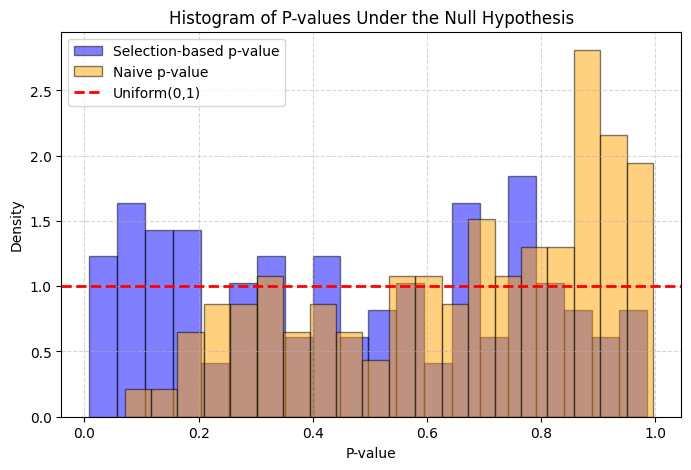

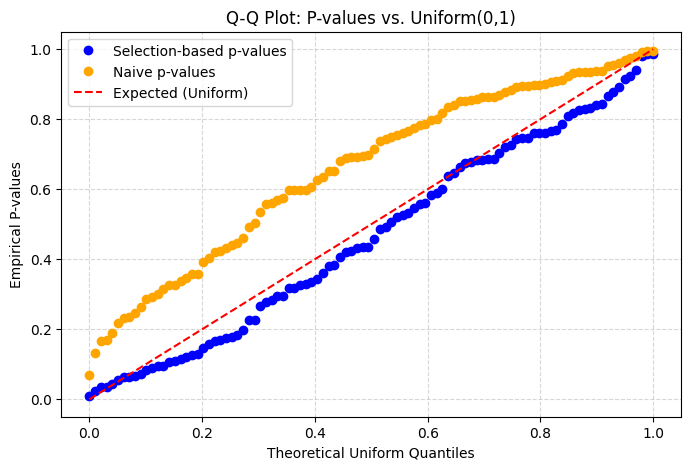

In [86]:
check_p_value_uniformity(20,2,1,19,np.log(20),-1,100)

level:  1
-34.9105360875991
level:  1
-35.83383358691671
level:  1
-36.068972359869946
level:  1
-35.5598429074851
level:  1
-35.874069460143815
level:  1
-35.79351514083407
level:  1
-35.47971591715472
level:  1
-35.28795966804
level:  1
-35.66780097237833
level:  1
-35.75206791551216
level:  1
-35.608398267388395
level:  1
-33.97498893081338
level:  1
-35.44089341187515
level:  1
-35.86345881907667
level:  1
-35.44229283264218
level:  1
-35.15562663936783
level:  1
-34.42208167398579
level:  1
-34.15329279079505
level:  1
-34.756173367639974
level:  1
-34.37009005028463
level:  1
-35.59658546207067
level:  1
-35.58508532210522
level:  1
-35.510838001581405
level:  1
-34.80486754447814
level:  1
-35.391849320392325
level:  1
-35.73886317099176
level:  1
-34.85316426295368
level:  1
-35.43683319443403
level:  1
-34.127562686236395
level:  1
-34.301305433289784
level:  1
-35.12759215231168
level:  1
-35.38680392754725
level:  1
-35.559716337229965
level:  1
-35.789327341164935
level:  1

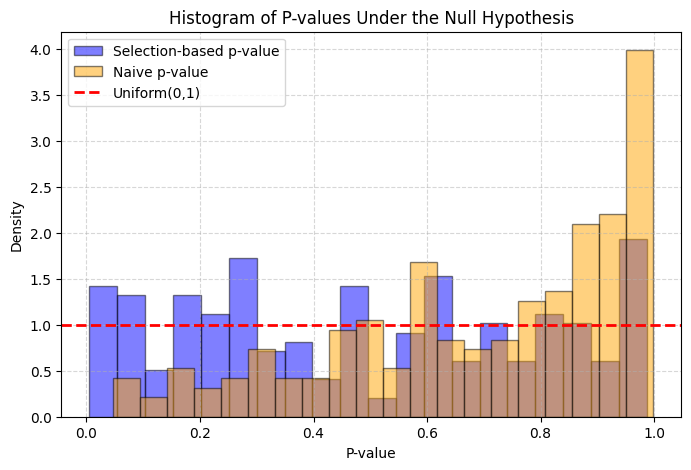

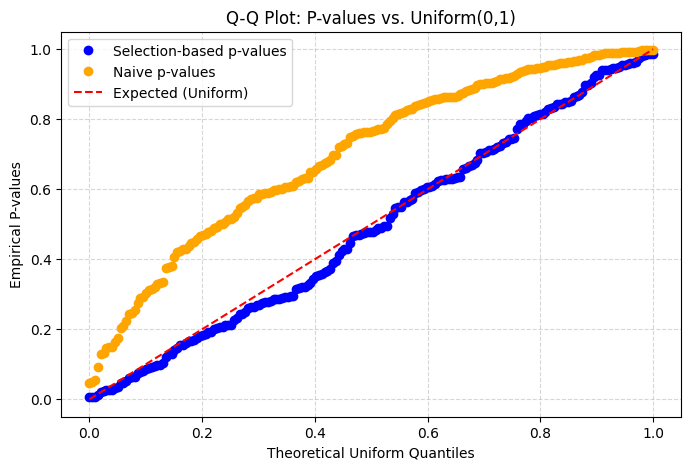

In [88]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
-225.26094438145776
level:  1
-229.05814031397438
level:  1
-223.22384131847673
level:  1
-233.18781005803123
level:  1
-218.00483483958254
level:  1
-222.881958956954
level:  1
-223.6995076661383
level:  1
-221.13747139091822
level:  1
-229.79288503527903
level:  1
-226.89392802846157
level:  1
-235.18375982275415
level:  1
-229.34002776086356
level:  1
-228.8094954832734
level:  1
-223.7280472171742
level:  1
-229.5471523248376
level:  1
-225.46605961437945
level:  1
-221.51231220782955
level:  1
-228.03876714982698
level:  1
-229.22108717296726
level:  1
-235.46811155039768
level:  1
-224.9282050886825
level:  1
-228.0482724982072
level:  1
-222.57592468809526
level:  1
-217.34190479940423
level:  1
-225.75255908770407
level:  1
-225.7744038737901
level:  1
-228.20436557779328
level:  1
-228.21351438997533
level:  1
-221.31952041291675
level:  1
-226.32461957943445
level:  1
-221.49387239257544
level:  1
-234.13581394277173
level:  1
-229.1962108962283
level:  1
-221.97705

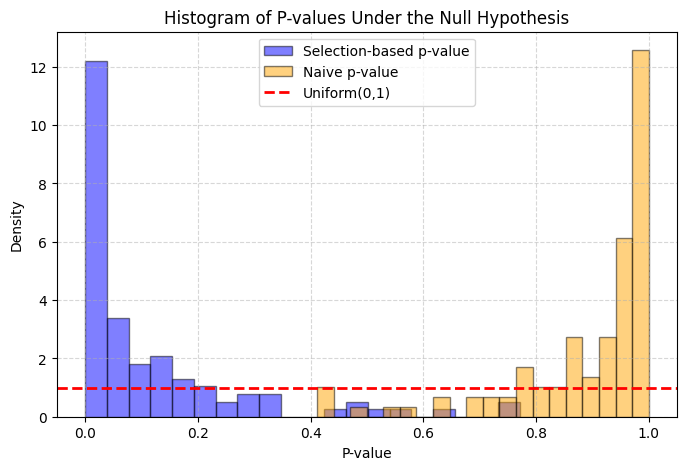

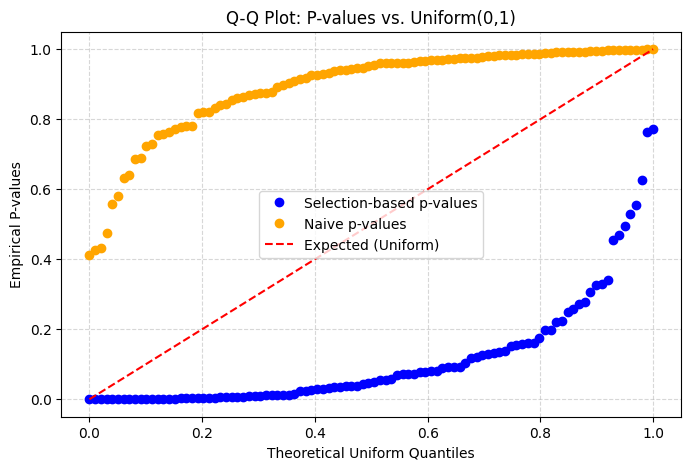

In [84]:
check_p_value_uniformity(20,15,1,19,1,-1,100)

level:  1
-5.953430953546688
level:  1
-5.918415251688836
level:  1
-5.807449591686842
level:  1
-5.915730866135025
level:  1
-5.847341758964905
level:  1
-5.920512551472791
level:  1
-5.834492977672216
level:  1
-5.777682327491377
level:  1
-5.859740702449299
level:  1
-5.949834556770279
level:  1
-5.799577800479197
level:  1
-5.957126459625757
level:  1
-5.8248720380348376
level:  1
-5.839540166633486
level:  1
-5.7984799409476935
level:  1
-5.824262633699647
level:  1
-5.889510179234982
level:  1
-5.860394555367364
level:  1
-5.8901299547896215
level:  1
-5.810747736295406
level:  1
-5.812850404447378
level:  1
-5.764632948076432
level:  1
-5.901081792221447
level:  1
-5.890703278427624
level:  1
-5.853310299878849
level:  1
-5.786727095190874
level:  1
-5.947115501918756
level:  1
-5.908951522122971
level:  1
-5.8222673266449565
level:  1
-5.875967199016218
level:  1
-5.867689410943708
level:  1
-5.919583560008602
level:  1
-5.877415323649341
level:  1
-5.893952473753313
level:  1


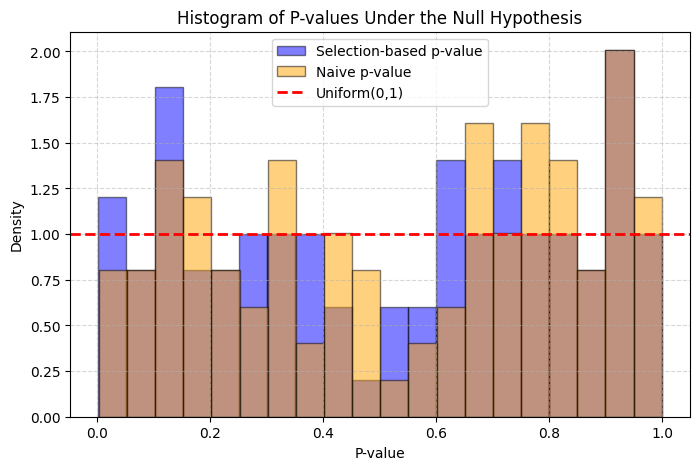

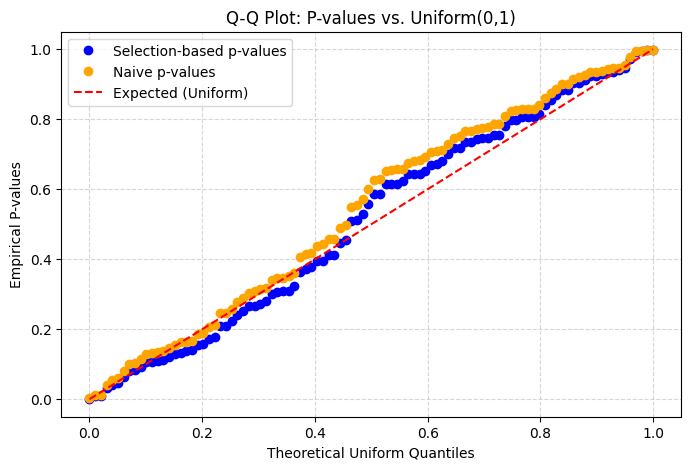

In [87]:
check_p_value_uniformity(20,2,1,19,10,-1,100)

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

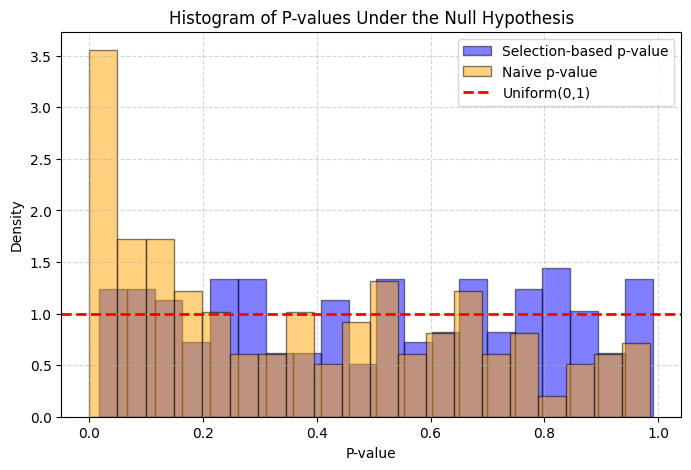

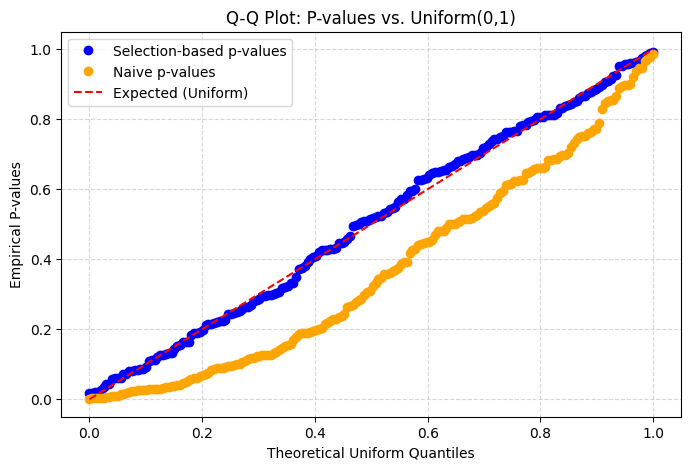

In [31]:
check_p_value_uniformity(20,2,1,3,np.log(20),-1,200)

In [ ]:
check_p_value_uniformity(20,30,1,19,np.log(20),-1,200)

In [ ]:
np.log(20)

level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6


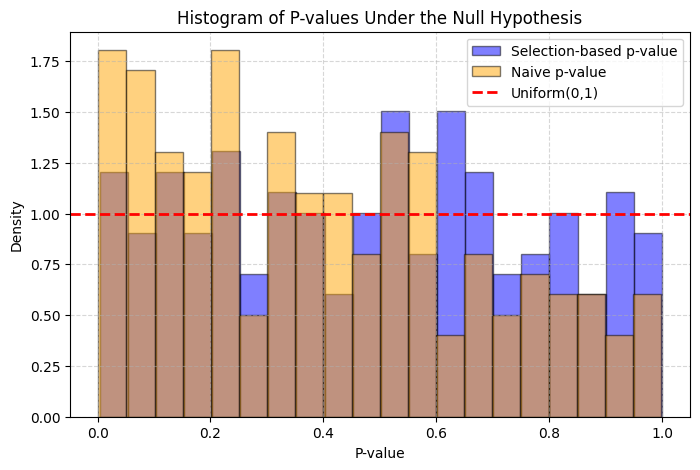

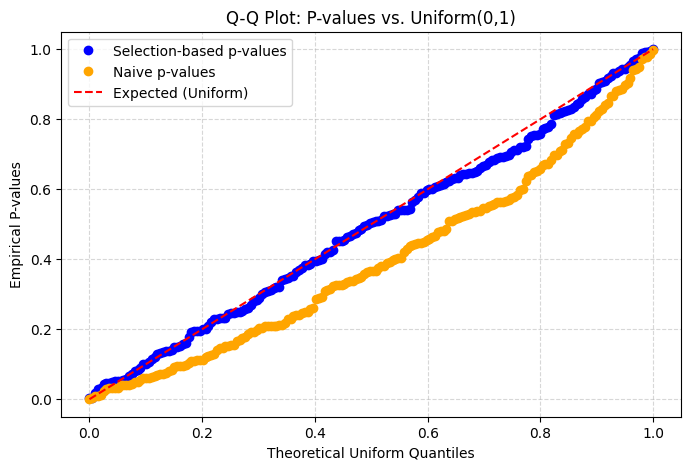

In [35]:
check_p_value_uniformity(10,15,1,3,np.log(10),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


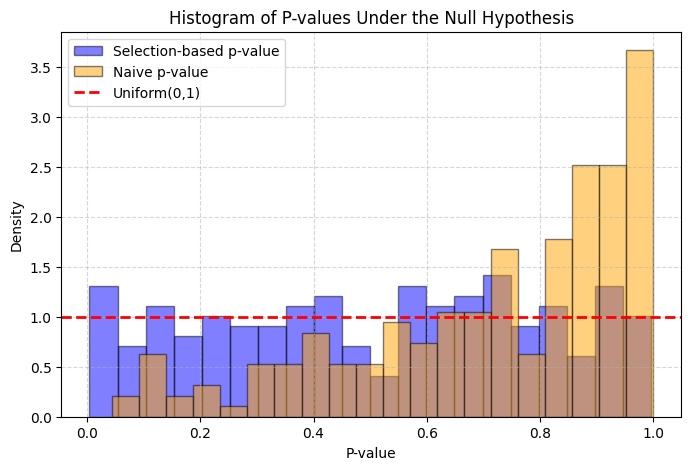

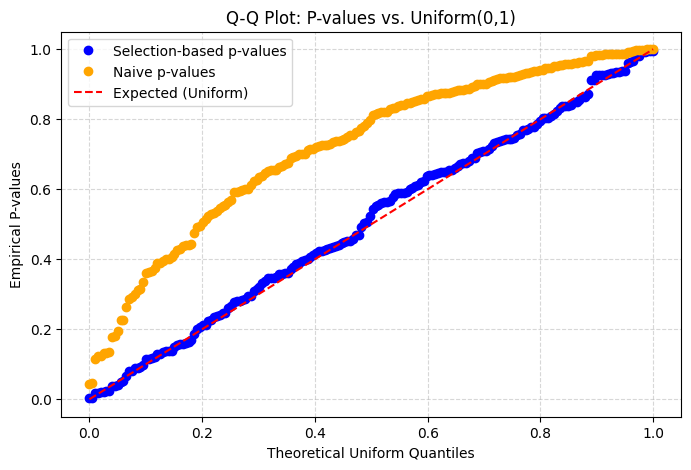

In [37]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


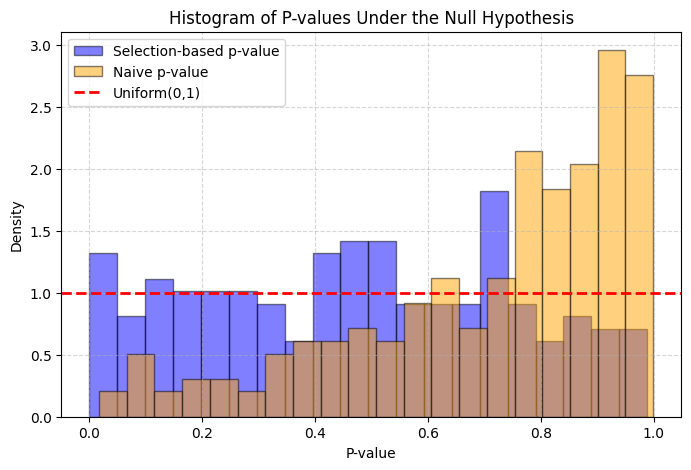

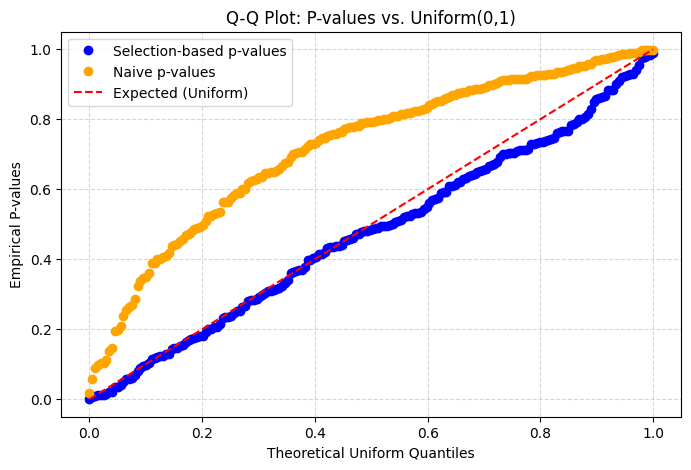

In [26]:
check_p_value_uniformity(30,15,1,29,np.log(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


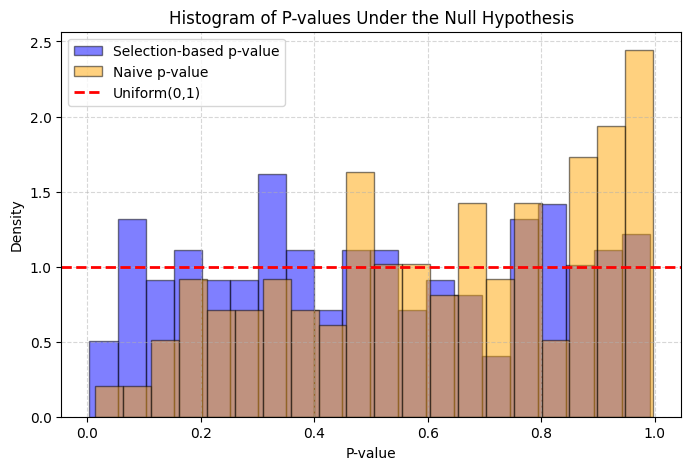

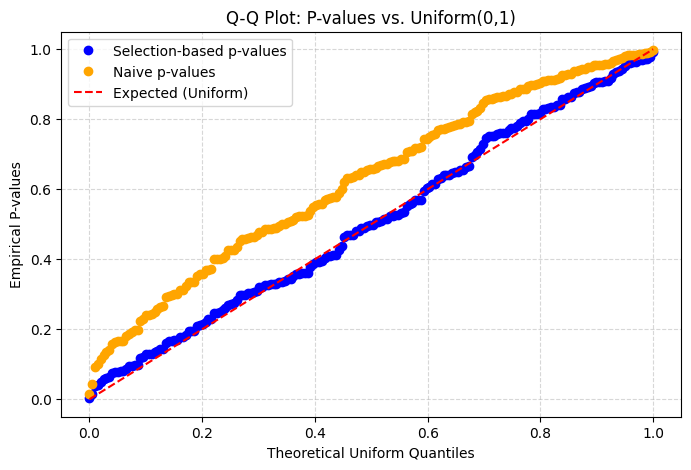

In [28]:
check_p_value_uniformity(30,15,1,29,np.sqrt(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


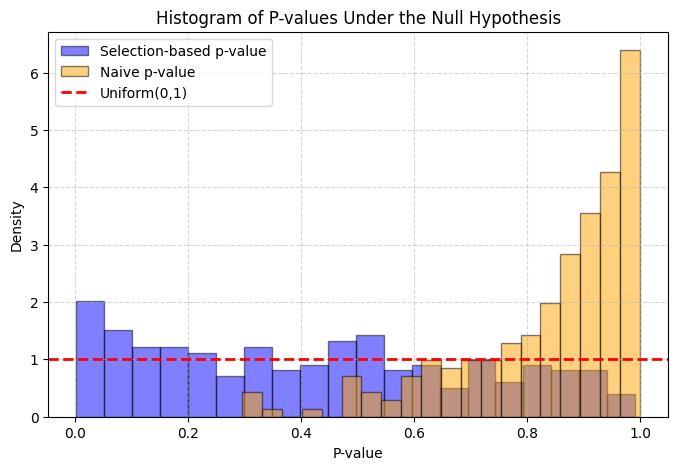

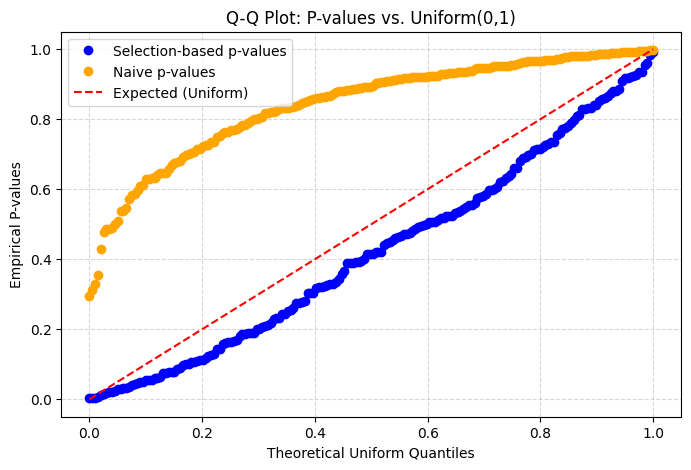

In [51]:
check_p_value_uniformity(10,2,1,9,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


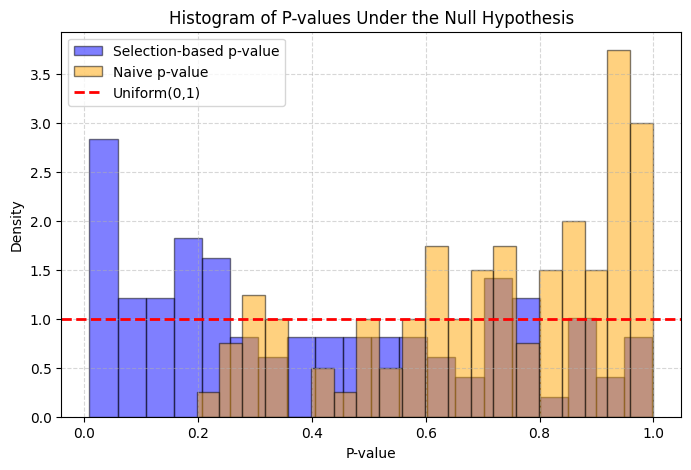

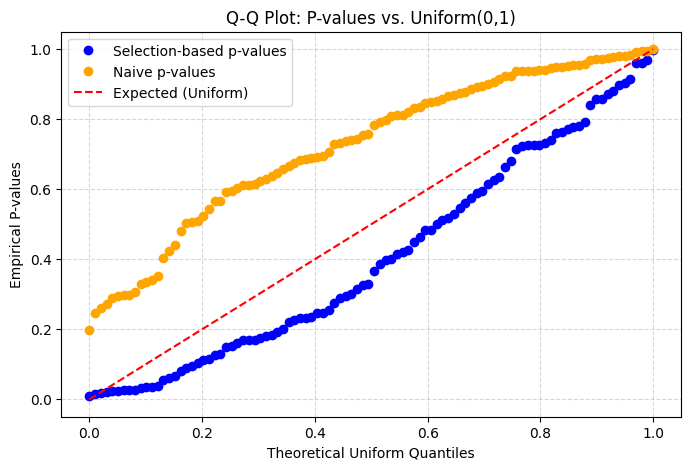

In [48]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


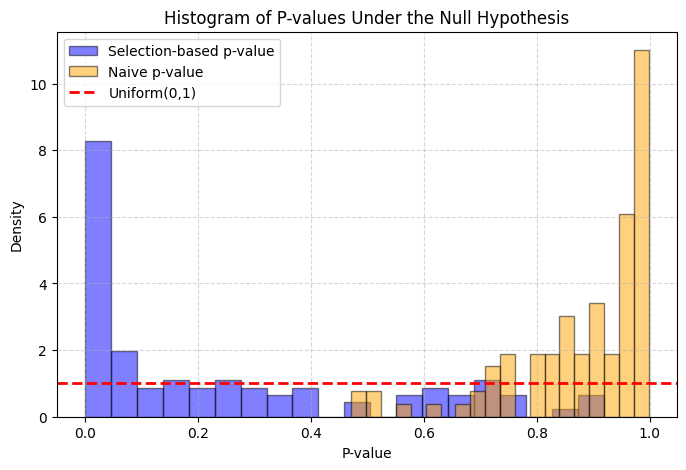

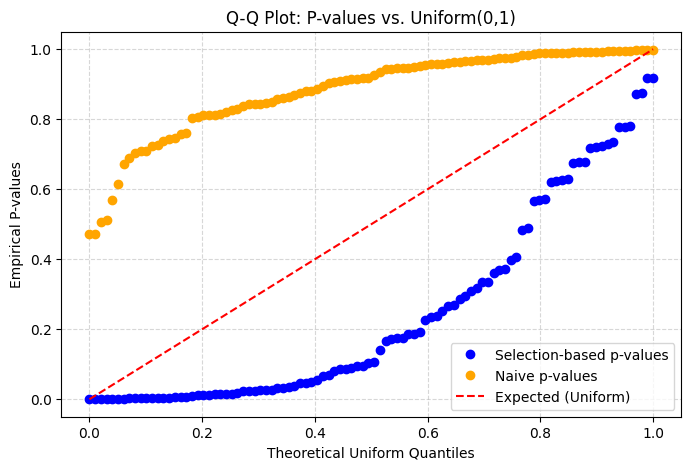

In [50]:
check_p_value_uniformity(30,2,1,29,1,-1,100)

In [ ]:
check_p_value_uniformity(20,2,1,19,5,-1,100)

In [ ]:
check_p_value_uniformity(100,30,1,99,5,-1,50)

In [ ]:
check_p_value_uniformity(20,15,1,10,1*np.sqrt(20),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,10,1*np.sqrt(30),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,3,1*np.sqrt(30),-1,200)

In [ ]:
def plot_p_value(stat_grid, cdf, observed_target, p_value):
    observed_cdf_value = np.interp(observed_target, stat_grid, cdf)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(stat_grid, cdf, label="CDF", color="blue", lw=2)
    plt.axvline(observed_target, color='red', linestyle='dashed', lw=2, label="Observed Target")
    
    plt.fill_between(stat_grid, cdf, 1, where=(stat_grid >= observed_target), color='red', alpha=0.3, label="p-value region")

    plt.text(observed_target, 0.05, f"Observed Target = {observed_target:.3f}", color='red', fontsize=12, rotation=90, verticalalignment='bottom')
    plt.text(stat_grid[-1]*0.85, 0.8, f"p-value = {p_value:.4f}", color='red', fontsize=14, bbox=dict(facecolor='white', edgecolor='red'))

    plt.xlabel(r"$X$ (Test Statistic)")
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title("Visualization of p-value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
  
    plt.show()

In [ ]:
grid = np.linspace(0.00001, 15, num=1000)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
X, y = make_blobs(n_samples=50, centers=4, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[3]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent

In [ ]:
node

In [ ]:
model.merge_inference(node)

In [ ]:
model.existing_clusters_log.keys()

In [ ]:
model.distance_matrix

In [ ]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


In [ ]:
model.get_all_winning_pairs()

In [ ]:
np.random.normal(0,1,(10,1))

In [ ]:
X_grid = np.array([
    [-3.41284633,  8.94302295],
    [-6.63766492, -8.79338984],
    [-5.46153354,  8.71814827],
    [-5.59752253,  8.4386312],
    [ 4.17646114,  1.50743993]
])


In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[3,:].reshape(1,-1)
data_cluster = X_grid[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
        

In [ ]:
distances

In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[0,:].reshape(1,-1)
data_cluster = X_grid[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[3,:].reshape(1,-1)
data_cluster = X[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[0,:].reshape(1,-1)
data_cluster = X[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances